In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from google.colab import files

# ============================================================
# DONNÉES COMMUNES AUX CAMPAGNES
# ============================================================

donnees_comparaison = pd.DataFrame({

    "Echantillon": [
        "1-A", "1-B", "1-C", "1-E", "1-F",
        "2-B", "2-D",
        "4-A", "4-C", "4-D", "4-E",
        "5-A", "5-B", "5-C", "5-E", "5-G", "5-H"
    ],

    # --------------------------------------------------------
    # Pertes diffuses à 100 °C
    # --------------------------------------------------------

    "s_loss_100_1": [
        1.109589e-2,
        9.814430e-3,
        1.246587e-2,
        5.733321e-3,
        1.418608e-2,
        9.529005e-3,
        6.026402e-3,
        9.179489e-3,
        8.844678e-3,
        8.763001e-3,
        7.061927e-3,
        6.429946e-3,
        6.097562e-3,
        6.748115e-3,
        6.580740e-3,
        6.561742e-3,
        5.925424e-3
    ],

    "s_loss_100_2": [
        6.748821e-3,
        8.462619e-3,
        8.585224e-3,
        7.051828e-3,
        1.020618e-2,
        8.452115e-3,
        7.006665e-3,
        9.650450e-3,
        1.027278e-2,
        7.048493e-3,
        7.565341e-3,
        6.271433e-3,
        5.719851e-3,
        7.116660e-3,
        5.840215e-3,
        6.658845e-3,
        6.120376e-3
    ],

    # --------------------------------------------------------
    # Perte diffuse à 50 °C
    # --------------------------------------------------------

    "s_loss_50": [
        3.570821e-3,
        2.602695e-3,
        2.897771e-3,
        2.642198e-3,
        3.093887e-3,
        2.978281e-3,
        2.617378e-3,
        3.017459e-3,
        2.788261e-3,
        2.458416e-3,
        2.622527e-3,
        2.428219e-3,
        3.321285e-3,
        2.386750e-3,
        2.460482e-3,
        2.519906e-3,
        2.238095e-3
    ],

    # --------------------------------------------------------
    # Conductivités à 100 °C
    # --------------------------------------------------------

    "lambda_100_1": [
        0.106704,
        0.217692,
        0.006408,
        0.018352,
        0.271094,
        0.115865,
        0.005474,
        0.068089,
        0.071013,
        0.023127,
        0.019509,
        0.016263,
        0.028934,
        0.049588,
        0.040705,
        0.051441,
        0.031648
    ],

    "lambda_100_2": [
        0.069023,
        0.267875,
        0.018331,
        0.023703,
        0.174152,
        0.144560,
        0.055888,
        0.047854,
        0.073511,
        0.035506,
        0.005466,
        0.100926,
        0.054285,
        0.015845,
        0.031084,
        0.027993,
        0.033218
    ],

    # --------------------------------------------------------
    # Conductivité à 50 °C
    # --------------------------------------------------------

    "lambda_50": [
        0.061794,
        0.316231,
        0.203342,
        0.112324,
        0.062587,
        0.161472,
        0.146130,
        0.058077,
        0.125194,
        0.057214,
        0.065428,
        0.046523,
        0.026264,
        0.101085,
        0.046100,
        0.105591,
        0.112954
    ]
})

# ============================================================
# MOYENNES À 100 °C
# ============================================================

donnees_comparaison["s_loss_100_moyenne"] = (
    donnees_comparaison["s_loss_100_1"]
    + donnees_comparaison["s_loss_100_2"]
) / 2

donnees_comparaison["lambda_100_moyenne"] = (
    donnees_comparaison["lambda_100_1"]
    + donnees_comparaison["lambda_100_2"]
) / 2

# ============================================================
# CLASSIFICATION
# Séries 1 et 2 : polydisperses
# Séries 4 et 5 : monodisperses
# ============================================================

def famille_echantillon(nom):

    serie = int(nom.split("-")[0])

    if serie in [1, 2]:
        return "Polydisperse"

    elif serie in [4, 5]:
        return "Monodisperse"

    else:
        return "Autre"


donnees_comparaison["Famille"] = (
    donnees_comparaison["Echantillon"]
    .apply(famille_echantillon)
)

couleur_polydisperse = "#1f77b4"
couleur_monodisperse = "#d95f02"

couleurs = {
    "Polydisperse": couleur_polydisperse,
    "Monodisperse": couleur_monodisperse
}

display(donnees_comparaison)

,Echantillon,s_loss_100_1,s_loss_100_2,s_loss_50,lambda_100_1,lambda_100_2,lambda_50,s_loss_100_moyenne,lambda_100_moyenne,Famille
0,1-A,0.011096,0.006749,0.003571,0.106704,0.069023,0.061794,0.008922,0.087863,Polydisperse
1,1-B,0.009814,0.008463,0.002603,0.217692,0.267875,0.316231,0.009139,0.242783,Polydisperse
2,1-C,0.012466,0.008585,0.002898,0.006408,0.018331,0.203342,0.010526,0.012370,Polydisperse
3,1-E,0.005733,0.007052,0.002642,0.018352,0.023703,0.112324,0.006393,0.021027,Polydisperse
4,1-F,0.014186,0.010206,0.003094,0.271094,0.174152,0.062587,0.012196,0.222623,Polydisperse
5,2-B,0.009529,0.008452,0.002978,0.115865,0.144560,0.161472,0.008991,0.130213,Polydisperse
6,2-D,0.006026,0.007007,0.002617,0.005474,0.055888,0.146130,0.006517,0.030681,Polydisperse
7,4-A,0.009179,0.009650,0.003017,0.068089,0.047854,0.058077,0.009415,0.057971,Monodisperse
8,4-C,0.008845,0.010273,0.002788,0.071013,0.073511,0.125194,0.009559,0.072262,Monodisperse
9,4-D,0.008763,0.007048,0.002458,0.023127,0.035506,0.057214,0.007906,0.029317,Monodisperse


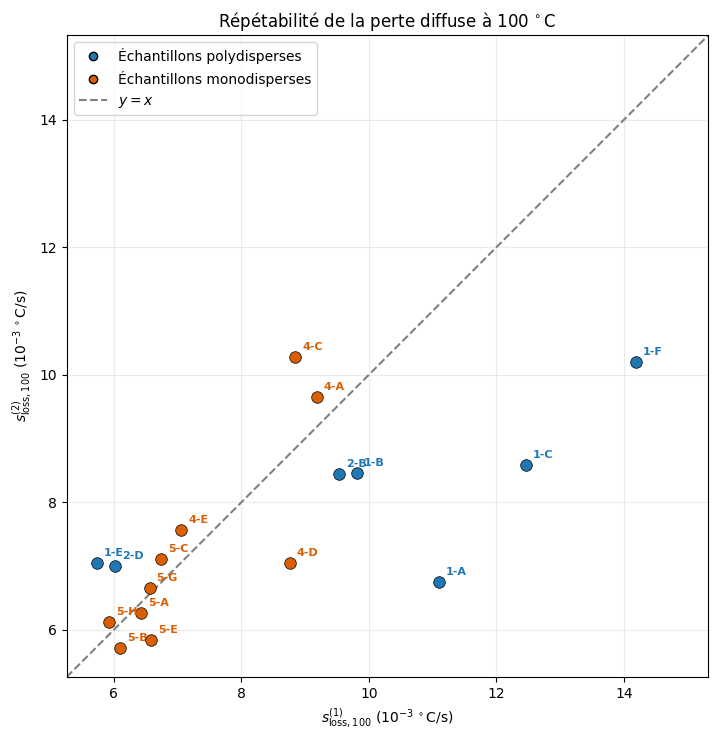

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 7.5))

x = donnees_comparaison["s_loss_100_1"] * 1e3
y = donnees_comparaison["s_loss_100_2"] * 1e3

for _, row in donnees_comparaison.iterrows():

    xi = row["s_loss_100_1"] * 1e3
    yi = row["s_loss_100_2"] * 1e3

    couleur = couleurs[row["Famille"]]

    ax.scatter(
        xi,
        yi,
        s=70,
        color=couleur,
        edgecolor="black",
        linewidth=0.5,
        zorder=3
    )

    ax.annotate(
        row["Echantillon"],
        (xi, yi),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        color=couleur,
        fontweight="bold"
    )

# ------------------------------------------------------------
# Droite idéale y = x
# ------------------------------------------------------------

lim_min = min(x.min(), y.min()) * 0.92
lim_max = max(x.max(), y.max()) * 1.08

ax.plot(
    [lim_min, lim_max],
    [lim_min, lim_max],
    linestyle="--",
    linewidth=1.5,
    color="gray",
    label=r"$s_{\mathrm{loss}}^{(2)}=s_{\mathrm{loss}}^{(1)}$"
)

ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)

ax.set_aspect("equal", adjustable="box")

ax.set_xlabel(
    r"$s_{\mathrm{loss},100}^{(1)}$ "
    r"($10^{-3}\,^\circ\mathrm{C/s}$)"
)

ax.set_ylabel(
    r"$s_{\mathrm{loss},100}^{(2)}$ "
    r"($10^{-3}\,^\circ\mathrm{C/s}$)"
)

ax.set_title(
    r"Répétabilité de la perte diffuse à $100\,^\circ$C"
)

legende = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        color=couleur_polydisperse,
        markeredgecolor="black",
        label="Échantillons polydisperses"
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        color=couleur_monodisperse,
        markeredgecolor="black",
        label="Échantillons monodisperses"
    ),
    Line2D(
        [0], [0],
        linestyle="--",
        color="gray",
        label=r"$y=x$"
    )
]

ax.legend(handles=legende)

ax.grid(alpha=0.25)

fig.tight_layout()

nom_pdf = "/content/repetabilite_sloss_100.pdf"
fig.savefig(nom_pdf, dpi=300, bbox_inches="tight")

plt.show()


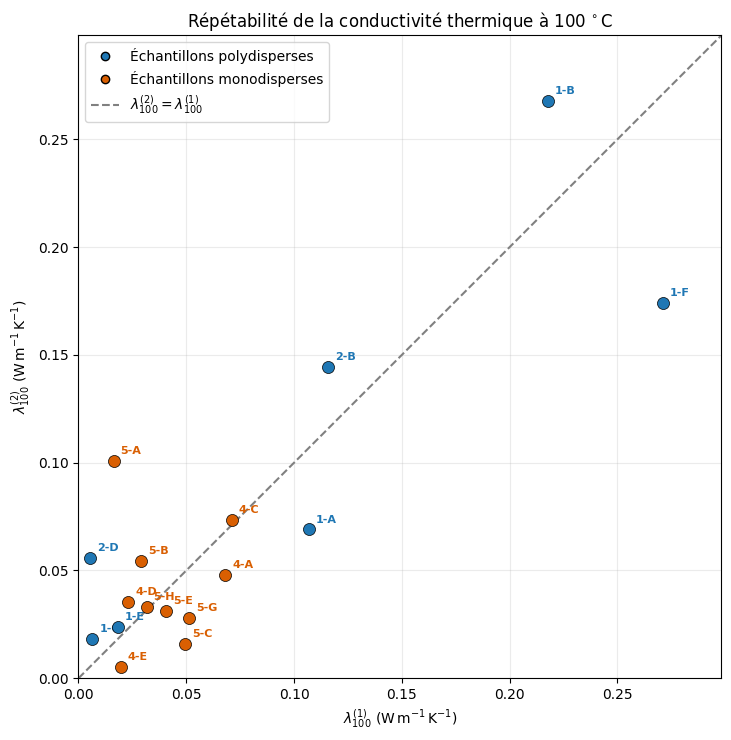

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 7.5))

x = donnees_comparaison["lambda_100_1"]
y = donnees_comparaison["lambda_100_2"]

for _, row in donnees_comparaison.iterrows():

    xi = row["lambda_100_1"]
    yi = row["lambda_100_2"]

    couleur = couleurs[row["Famille"]]

    ax.scatter(
        xi,
        yi,
        s=75,
        color=couleur,
        edgecolor="black",
        linewidth=0.5,
        zorder=3
    )

    ax.annotate(
        row["Echantillon"],
        (xi, yi),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        color=couleur,
        fontweight="bold"
    )

# ------------------------------------------------------------
# Droite parfaite lambda2 = lambda1
# ------------------------------------------------------------

lim_min = 0
lim_max = max(x.max(), y.max()) * 1.10

ax.plot(
    [lim_min, lim_max],
    [lim_min, lim_max],
    linestyle="--",
    linewidth=1.5,
    color="gray"
)

ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)

ax.set_aspect("equal", adjustable="box")

ax.set_xlabel(
    r"$\lambda_{100}^{(1)}$ "
    r"($\mathrm{W\,m^{-1}\,K^{-1}}$)"
)

ax.set_ylabel(
    r"$\lambda_{100}^{(2)}$ "
    r"($\mathrm{W\,m^{-1}\,K^{-1}}$)"
)

ax.set_title(
    r"Répétabilité de la conductivité thermique à $100\,^\circ$C"
)

legende = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        color=couleur_polydisperse,
        markeredgecolor="black",
        label="Échantillons polydisperses"
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        color=couleur_monodisperse,
        markeredgecolor="black",
        label="Échantillons monodisperses"
    ),
    Line2D(
        [0], [0],
        linestyle="--",
        color="gray",
        label=r"$\lambda_{100}^{(2)}=\lambda_{100}^{(1)}$"
    )
]

ax.legend(handles=legende)

ax.grid(alpha=0.25)

fig.tight_layout()

nom_pdf = "/content/repetabilite_lambda_100.pdf"
fig.savefig(nom_pdf, dpi=300, bbox_inches="tight")

plt.show()


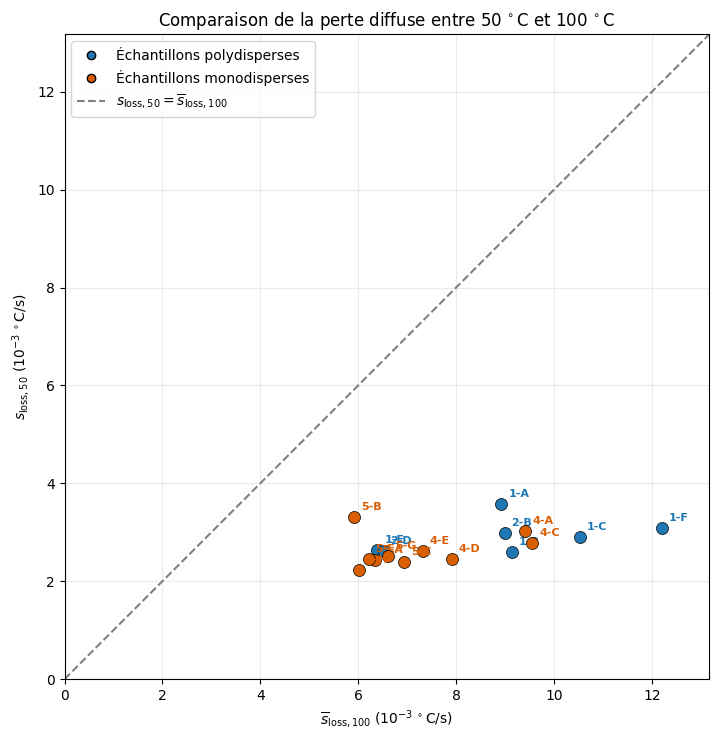

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 7.5))

x = donnees_comparaison["s_loss_100_moyenne"] * 1e3
y = donnees_comparaison["s_loss_50"] * 1e3

for _, row in donnees_comparaison.iterrows():

    xi = row["s_loss_100_moyenne"] * 1e3
    yi = row["s_loss_50"] * 1e3

    couleur = couleurs[row["Famille"]]

    ax.scatter(
        xi,
        yi,
        s=75,
        color=couleur,
        edgecolor="black",
        linewidth=0.5,
        zorder=3
    )

    ax.annotate(
        row["Echantillon"],
        (xi, yi),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        color=couleur,
        fontweight="bold"
    )

lim_min = 0
lim_max = max(x.max(), y.max()) * 1.08

ax.plot(
    [lim_min, lim_max],
    [lim_min, lim_max],
    linestyle="--",
    linewidth=1.5,
    color="gray"
)

ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)

ax.set_aspect("equal", adjustable="box")

ax.set_xlabel(
    r"$\overline{s}_{\mathrm{loss},100}$ "
    r"($10^{-3}\,^\circ\mathrm{C/s}$)"
)

ax.set_ylabel(
    r"$s_{\mathrm{loss},50}$ "
    r"($10^{-3}\,^\circ\mathrm{C/s}$)"
)

ax.set_title(
    r"Comparaison de la perte diffuse entre $50\,^\circ$C et $100\,^\circ$C"
)

legende = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        color=couleur_polydisperse,
        markeredgecolor="black",
        label="Échantillons polydisperses"
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        color=couleur_monodisperse,
        markeredgecolor="black",
        label="Échantillons monodisperses"
    ),
    Line2D(
        [0], [0],
        linestyle="--",
        color="gray",
        label=r"$s_{\mathrm{loss},50}=\overline{s}_{\mathrm{loss},100}$"
    )
]

ax.legend(handles=legende)

ax.grid(alpha=0.25)

fig.tight_layout()

nom_pdf = "/content/comparaison_sloss_50_100.pdf"
fig.savefig(nom_pdf, dpi=300, bbox_inches="tight")

plt.show()


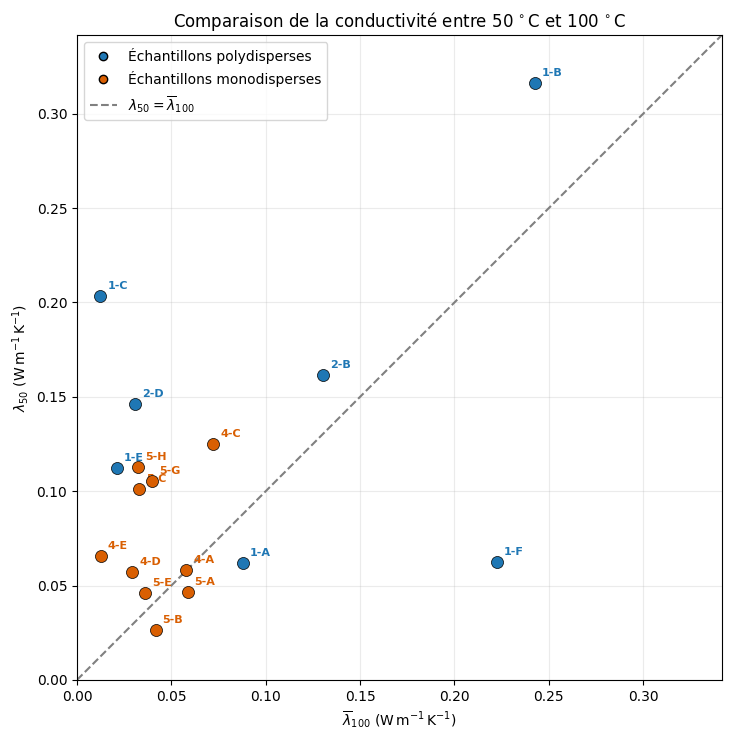

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 7.5))

x = donnees_comparaison["lambda_100_moyenne"]
y = donnees_comparaison["lambda_50"]

for _, row in donnees_comparaison.iterrows():

    xi = row["lambda_100_moyenne"]
    yi = row["lambda_50"]

    couleur = couleurs[row["Famille"]]

    ax.scatter(
        xi,
        yi,
        s=75,
        color=couleur,
        edgecolor="black",
        linewidth=0.5,
        zorder=3
    )

    ax.annotate(
        row["Echantillon"],
        (xi, yi),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        color=couleur,
        fontweight="bold"
    )

lim_min = 0
lim_max = max(x.max(), y.max()) * 1.08

ax.plot(
    [lim_min, lim_max],
    [lim_min, lim_max],
    linestyle="--",
    linewidth=1.5,
    color="gray"
)

ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)

ax.set_aspect("equal", adjustable="box")

ax.set_xlabel(
    r"$\overline{\lambda}_{100}$ "
    r"($\mathrm{W\,m^{-1}\,K^{-1}}$)"
)

ax.set_ylabel(
    r"$\lambda_{50}$ "
    r"($\mathrm{W\,m^{-1}\,K^{-1}}$)"
)

ax.set_title(
    r"Comparaison de la conductivité entre $50\,^\circ$C et $100\,^\circ$C"
)

legende = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        color=couleur_polydisperse,
        markeredgecolor="black",
        label="Échantillons polydisperses"
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        color=couleur_monodisperse,
        markeredgecolor="black",
        label="Échantillons monodisperses"
    ),
    Line2D(
        [0], [0],
        linestyle="--",
        color="gray",
        label=r"$\lambda_{50}=\overline{\lambda}_{100}$"
    )
]

ax.legend(handles=legende)

ax.grid(alpha=0.25)

fig.tight_layout()

nom_pdf = "/content/comparaison_lambda_50_100.pdf"
fig.savefig(nom_pdf, dpi=300, bbox_inches="tight")

plt.show()
